In [5]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_groq import ChatGroq
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [6]:
load_dotenv()

True

In [34]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.7
)

In [35]:
loader = PyPDFLoader("ritesh_AI.pdf")
docs = loader.load()

In [36]:
for i, doc in enumerate(docs, 1):
    print(f"\n{'='*100}")
    print(f"📄 PAGE {i}")
    print(f"{'='*100}")
    print(doc.page_content)


📄 PAGE 1
Ritesh Patel
+91 8858295418|riteshpatel1884@gmail.com |linkedin/riteshpatel1884 |github/riteshpatel1884
Education
KIET Deemed to be UniversityGhaziabad, India
B.Tech in Computer Science — 7.48 GPA Oct 2023 - June 2027
Rani Laxmi Bai Memorial SchoolLucknow, India
Class XII (ISC) — 84% 2021-2022
Rani Laxmi Bai Memorial SchoolLucknow, India
Class X (ICSE) — 86% 2019-2020
Experience
Airkrit India|Internship|Data AnalystMay - Aug 2026
• Built data preprocessing pipelines (Python, Pandas, NumPy) on 10K+ records, applying cleaning, feature
engineering, and anomaly detection techniques
• Applied statistical analysis and pattern detection to identify sales and customer behavior trends, feeding into 15+
visualizations for stakeholder decision-making
• Automated report generation using LLM-based summarization, reducing manual reporting time by 30%
Projects
RAGOps - Production RAG Evaluation & Optimization Platform|(github) Aug - Sep 2026
• Built a configurable RAG pipeline builder suppo

In [37]:
len(docs)

1

In [38]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)
len(chunks)

8

In [39]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)
vector_store = FAISS.from_documents(chunks, embeddings)
vector_store.save_local("faiss_index")


In [40]:
vector_store

In [41]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [42]:
ans = retriever.invoke("What is Rainfall Measurement?")
ans

[Document(id='0c00e614-dca4-4545-8646-e9f045ee87e8', metadata={'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-09-08T09:44:45+00:00', 'author': '', 'keywords': '', 'moddate': '2026-09-08T09:44:45+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) kpathsea version 6.4.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'ritesh_AI.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='• Built data preprocessing pipelines (Python, Pandas, NumPy) on 10K+ records, applying cleaning, feature\nengineering, and anomaly detection techniques\n• Applied statistical analysis and pattern detection to identify sales and customer behavior trends, feeding into 15+\nvisualizations for stakeholder decision-making\n• Automated report generation using LLM-based summarization, reducing manual reporting time by 30%\nProjects'),
 Document(id='6c1fb15c-46b3-4f60-a978-2da0700eb09f', metadata={'producer': 'pd

In [43]:
@tool
def rag_tool(query: str) -> str:
    """
    Retrieve relevant information from the PDF document.

    Use this tool when the user asks factual or conceptual questions
    that may be answered using the stored PDF documents.

    Args:
        query: The question or search query used to retrieve PDF content.
    """

    documents = retriever.invoke(query)

    if not documents:
        return "No relevant information was found in the PDF."

    formatted_documents = []

    for index, document in enumerate(documents, start=1):
        source = document.metadata.get("source", "Unknown source")
        page = document.metadata.get("page", "Unknown page")

        formatted_documents.append(
            f"Document {index}\n"
            f"Source: {source}\n"
            f"Page: {page}\n"
            f"Content: {document.page_content}"
        )

    return "\n\n".join(formatted_documents)


In [44]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [45]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [46]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


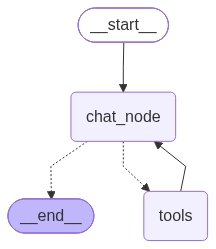

In [47]:
tool_node = ToolNode(tools)  # Executes tool calls
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")  
chatbot = graph.compile()

chatbot

In [48]:
# Regular chat - dont need any tool
result = chatbot.invoke({"messages": [HumanMessage(content="Hello")]})

print(result["messages"][-1].content)

Hello! How can I help you today?


In [51]:
result = chatbot.invoke({"messages": [HumanMessage(content="What is my name?")]})

print(result["messages"][-1].content)

Your name is **Ritesh Patel**.
